#  Learning to Rank with LightGBM + Hyperopt
## Semfe Lab 23 April 2026

**Dataset:** [Large Retail Data Set for EDA](https://www.kaggle.com/datasets/utkalk/large-retail-data-set-for-eda)  
1 000 000 rows × 78 columns of retail transaction & customer data.

**Goal:** Build a production-grade **Learning-to-Rank** pipeline that ranks customers by their expected revenue, so a marketing campaign can target the top-N highest-value individuals.

**What you will learn:**
- How LightGBM implements ranking (LambdaMART / XE-NDCG)
- What every key hyperparameter does
- How Hyperopt performs Bayesian optimisation with TPE
- How to evaluate a ranker with NDCG@k and Data Leakage Case.
---


## Section 0 — Setup & Imports

In [73]:
# Install required libraries (run once)
# !pip install lightgbm hyperopt --quiet

import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
from hyperopt.pyll.base import scope
from functools import partial

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
SEED = 42
print("Libraries loaded")
print(f"LightGBM version : {lgb.__version__}")

Libraries loaded
LightGBM version : 3.3.5


## Section 1 — Load Data

The dataset lives at `retail_data.csv` inside Kaggle.  
Outside Kaggle you can download it with `kagglehub`:

```python
import kagglehub
path = kagglehub.dataset_download("utkalk/large-retail-data-set-for-eda")
```


In [74]:
# ── Kaggle path ──────────────────────────────────────────────────────────────
CSV_PATH = "retail_data.csv"

# ── Local / kagglehub path (uncomment if running outside Kaggle) ──────────────
# import kagglehub
# base = kagglehub.dataset_download("utkalk/large-retail-data-set-for-eda")
# CSV_PATH = os.path.join(base, "retail_data.csv")

print("Loading dataset …")
df = pd.read_csv(CSV_PATH, encoding="unicode_escape")

df.head(10)

print(f"\nShape: {df.shape}")

print(f"\nColumns list: {df.columns.to_list()}")

print("\nData types:")
print(df.dtypes)

print("\nTotal missing values:", df.isnull().sum().sum())

print("\nMissing values per column:")
missing = df.isnull().sum().sort_values(ascending=False)
print(missing.head(15))

print(df['total_sales'].value_counts())

Loading dataset …

Shape: (1000000, 78)

Columns list: ['customer_id', 'age', 'gender', 'income_bracket', 'loyalty_program', 'membership_years', 'churned', 'marital_status', 'number_of_children', 'education_level', 'occupation', 'transaction_id', 'transaction_date', 'product_id', 'product_category', 'quantity', 'unit_price', 'discount_applied', 'payment_method', 'store_location', 'transaction_hour', 'day_of_week', 'week_of_year', 'month_of_year', 'avg_purchase_value', 'purchase_frequency', 'last_purchase_date', 'avg_discount_used', 'preferred_store', 'online_purchases', 'in_store_purchases', 'avg_items_per_transaction', 'avg_transaction_value', 'total_returned_items', 'total_returned_value', 'total_sales', 'total_transactions', 'total_items_purchased', 'total_discounts_received', 'avg_spent_per_category', 'max_single_purchase_value', 'min_single_purchase_value', 'product_name', 'product_brand', 'product_rating', 'product_review_count', 'product_stock', 'product_return_rate', 'product_s

## Section 2 — Brief Exploratory Data Analysis

Before building any model we inspect the target variable (`total_sales`) and a few key signals.


In [75]:
print("── Key numeric stats ──")
print(df[["age","total_sales","total_transactions",
          "days_since_last_purchase","quantity","unit_price"]].describe().round(2))

── Key numeric stats ──
              age  total_sales  total_transactions  days_since_last_purchase  \
count  1000000.00   1000000.00          1000000.00                1000000.00   
mean        48.50      5056.06               49.99                    182.03   
std         17.87      2859.10               28.57                    105.36   
min         18.00       100.01                1.00                      0.00   
25%         33.00      2577.87               25.00                     91.00   
50%         49.00      5059.70               50.00                    182.00   
75%         64.00      7534.80               75.00                    273.00   
max         79.00      9999.98               99.00                    364.00   

         quantity  unit_price  
count  1000000.00  1000000.00  
mean         5.00      500.26  
std          2.58      288.46  
min          1.00        1.00  
25%          3.00      250.31  
50%          5.00      500.41  
75%          7.00      750.16  

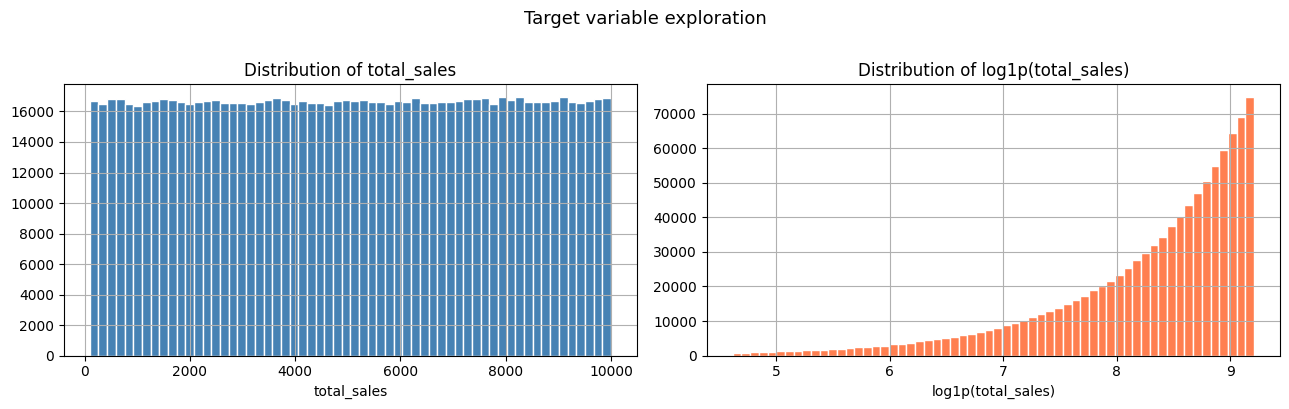

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df["total_sales"].hist(bins=60, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of total_sales")
axes[0].set_xlabel("total_sales")

np.log1p(df["total_sales"]).hist(bins=60, ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("Distribution of log1p(total_sales)")
axes[1].set_xlabel("log1p(total_sales)")

plt.suptitle("Target variable exploration", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

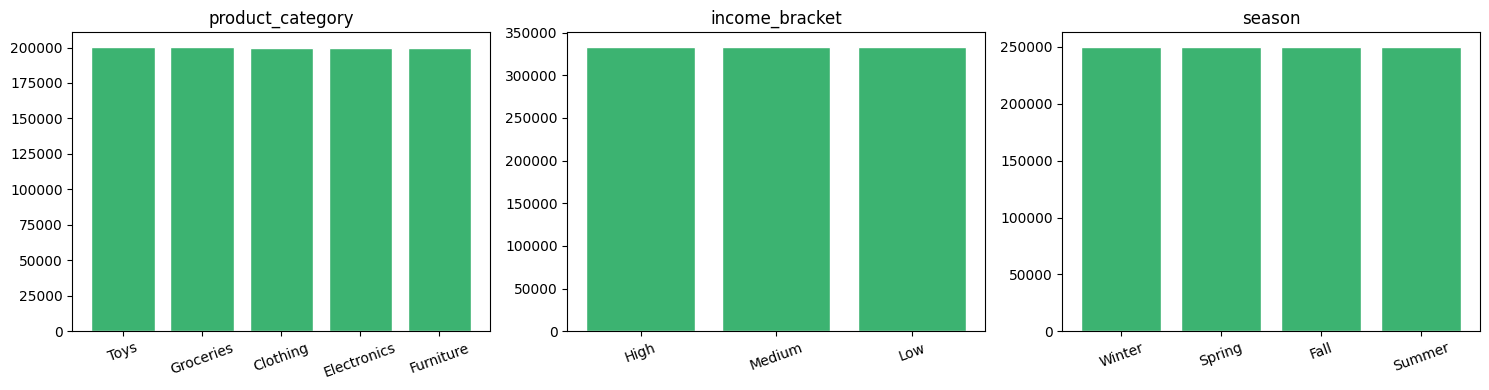

In [77]:
# Category breakdowns
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["product_category", "income_bracket", "season"]):
    vc = df[col].value_counts()
    ax.bar(vc.index, vc.values, color="mediumseagreen", edgecolor="white")
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

## Section 3 — Feature Engineering & Preprocessing

### Design decisions

| Step | Rationale |
|------|-----------|
| Derive `recency_months` | Normalised recency (days → months) |
| Compute `Total_Spend` | Transaction-level revenue = qty × price |
| Chronological 70/15/15 split | Simulates production: train on history, score the future |
| Quantile-bin `total_sales` → relevance labels | LightGBM ranker needs integer labels 0…K-1 |


In [44]:


# ════════════════════════════════════════════════════════════════
# SECTION A — TRANSACTION-LEVEL FEATURES
# (same as before, kept as-is)
# ════════════════════════════════════════════════════════════════

df["Total_Spend"]    = df["quantity"] * df["unit_price"]
df["discount_ratio"] = df["discount_applied"] / (df["unit_price"] + 1e-6)

# ════════════════════════════════════════════════════════════════
# SECTION B — CUSTOMER-LEVEL AGGREGATION
# Mirrors the production RFM + engagement pipeline from the doc.
# Everything is computed per customer_id then joined back to df.
# ════════════════════════════════════════════════════════════════

# ── B1. Recency (Section 1.1) ─────────────────────────────────────────────────
# days_since_last_purchase is already per-customer; just derive transforms.
cust_recency = df.groupby("customer_id").agg(
    recency_days  = ("days_since_last_purchase", "first"),
).reset_index()

cust_recency["recency_months"]  = cust_recency["recency_days"] / 30.5
cust_recency["recency_6m"]      = cust_recency["recency_days"].where(
                                      cust_recency["recency_days"] <= 180, 0)
cust_recency["recency_12m"]     = cust_recency["recency_days"].where(
                                      cust_recency["recency_days"] <= 365, 0)
cust_recency["sqrt_recency"]    = np.sqrt(cust_recency["recency_days"])

# ── B2. Lifetime Volume & Revenue (Section 1.2) ───────────────────────────────
cust_volume = df.groupby("customer_id").agg(
    lifetime_order_count     = ("transaction_id",        "nunique"),
    lifetime_order_dollars   = ("total_sales",           "first"),   # pre-aggregated
    lifetime_items_purchased = ("total_items_purchased", "first"),
    lifetime_total_quantity  = ("quantity",              "sum"),
    avg_purchase_value       = ("avg_purchase_value",    "first"),
    avg_transaction_value    = ("avg_transaction_value", "first"),
    avg_items_per_transaction= ("avg_items_per_transaction", "first"),
).reset_index()

# ── B3. AOV & derived statistical features (Section 6) ────────────────────────
cust_volume["AOV"] = (
    cust_volume["lifetime_order_dollars"] /
    cust_volume["lifetime_order_count"].replace(0, np.nan)
).fillna(0)

cust_volume["log_AOV"] = np.log1p(cust_volume["AOV"])

cust_volume["sqrt_lifetime_order_count"] = np.sqrt(
    (cust_volume["lifetime_order_count"] - 1).clip(lower=0)
)

# ── B4. Returns (ratio feature) ────────────────────────────────────────────────
cust_returns = df.groupby("customer_id").agg(
    lifetime_returned_items   = ("total_returned_items",  "first"),
    lifetime_returned_dollars = ("total_returned_value",  "first"),
).reset_index()

cust_returns["return_rate"] = (
    cust_returns["lifetime_returned_items"] /
    cust_volume.set_index("customer_id")["lifetime_items_purchased"]
               .reindex(cust_returns["customer_id"]).values
).fillna(0).clip(0, 1)

# ── B5. Holiday & quarterly seasonality (Sections 1.4, 1.5) ──────────────────
df["is_holiday_month"] = df["month_of_year"].isin([11, 12]).astype(int)
df["quarter"] = df["month_of_year"].apply(
    lambda m: 1 if m <= 3 else (2 if m <= 6 else (3 if m <= 9 else 4))
)

cust_holiday = (
    df[df["is_holiday_month"] == 1]
    .groupby("customer_id")
    .agg(
        lifetime_holiday_order_count   = ("transaction_id", "nunique"),
        lifetime_holiday_order_dollars = ("Total_Spend",    "sum"),
    )
    .reset_index()
)



# ── B6. Discount engagement (Section 2) ───────────────────────────────────────
cust_discount = df.groupby("customer_id").agg(
    lifetime_discounts_received = ("total_discounts_received", "first"),
    avg_discount_used           = ("avg_discount_used",        "first"),
    discount_order_count        = ("transaction_id",
                                   lambda x: (df.loc[x.index, "discount_applied"] > 0).sum()),
).reset_index()

cust_discount["catalogue_orders_pct"] = (
    cust_discount["discount_order_count"] /
    cust_volume.set_index("customer_id")["lifetime_order_count"]
               .reindex(cust_discount["customer_id"]).replace(0, np.nan).values
).fillna(0)

# ── B7. Engagement — app, social, email, web (Sections 4 & 5) ─────────────────
app_map = {"Low": 0, "Medium": 1, "High": 2}
df["app_usage_num"]    = df["app_usage"].map(app_map).fillna(1)
df["social_media_num"] = df["social_media_engagement"].map(app_map).fillna(1)

cust_engage = df.groupby("customer_id").agg(
    online_purchases       = ("online_purchases",       "first"),
    in_store_purchases     = ("in_store_purchases",     "first"),
    website_visits         = ("website_visits",         "first"),
    customer_support_calls = ("customer_support_calls", "first"),
    app_usage_num          = ("app_usage_num",          "first"),
    social_media_num       = ("social_media_num",       "first"),
    email_subscribed       = ("email_subscriptions",
                              lambda x: int((x == "Yes").iloc[0])),
).reset_index()

# Composite engagement score (analogous to email open rate + web visits in doc)
cust_engage["engagement_score"] = (
    cust_engage["app_usage_num"] +
    cust_engage["social_media_num"] +
    cust_engage["website_visits"] / 10 +
    cust_engage["email_subscribed"]
)

# Channel ratio: preference for digital vs in-store
total_channel = (cust_engage["online_purchases"] +
                 cust_engage["in_store_purchases"]).replace(0, np.nan)
cust_engage["online_channel_ratio"] = (
    cust_engage["online_purchases"] / total_channel
).fillna(0.5)

# ── B8. Loyalty / membership (Section 3) ──────────────────────────────────────
cust_loyalty = df.groupby("customer_id").agg(
    membership_years = ("membership_years", "first"),
    loyalty_program_bin = ("loyalty_program",
                           lambda x: int((x == "Yes").iloc[0])),
    churned_bin = ("churned",
                   lambda x: int((x == "Yes").iloc[0])),
).reset_index()

cust_loyalty["is_active"]     = cust_loyalty["loyalty_program_bin"]
# Renewal rate proxy: longer tenure → higher renewal tendency
cust_loyalty["renewal_rate"]  = (
    cust_loyalty["membership_years"] /
    (cust_loyalty["membership_years"] + 1)
)
# Churn risk: churned AND short tenure (recently lapsed)
cust_loyalty["is_perks_churn_risk"] = (
    (cust_loyalty["churned_bin"] == 1) &
    (cust_loyalty["membership_years"] <= 1)
).astype(int)


cust_demo = df.groupby("customer_id").agg(
    age                = ("age",                "first"),
    number_of_children = ("number_of_children", "first"),
    distance_to_store  = ("distance_to_store",  "first"),
).reset_index()

# ════════════════════════════════════════════════════════════════
# SECTION C — MERGE ALL CUSTOMER FEATURES BACK TO df
# ════════════════════════════════════════════════════════════════

cust_all = cust_recency.copy()
for cdf in [cust_volume, cust_returns, cust_holiday,
            cust_discount, cust_engage, cust_loyalty, cust_demo]:
    cust_all = cust_all.merge(cdf, on="customer_id", how="left")

# Drop raw recency_days (we keep the derived versions)
cust_all.drop(columns=["recency_days"], inplace=True, errors="ignore")

df = df.merge(cust_all, on="customer_id", how="left", suffixes=("", "_cust"))

print(f"Feature engineering done. df shape: {df.shape}")

Feature engineering done. df shape: (1000000, 166)


In [48]:
FEATURE_COLS = [

    # ── Recency (doc Section 1.1) ────────────────────────────────────────────
    "recency_months",           # base recency in months
    "recency_6m",               # days if within 6 months else 0
    "recency_12m",              # days if within 12 months else 0
    "sqrt_recency",             # sqrt-compressed recency (reduces skew)

    # ── Lifetime volume & revenue (doc Section 1.2) ──────────────────────────
    "lifetime_order_count",
    "lifetime_items_purchased",
    "lifetime_total_quantity",

    # ── Recent-period proxies — pre-aggregated in dataset (doc Section 1.3) ──
    "avg_purchase_value",
    "avg_transaction_value",
    "avg_items_per_transaction",

    # ── Holiday & catalog-period (doc Section 1.4) ───────────────────────────
    "lifetime_holiday_order_count",
    "lifetime_holiday_order_dollars",
    "is_holiday_month",         # transaction-level flag
    "catalogue_orders_pct",     # fraction of orders driven by discount/catalog

    # ── Quarterly seasonality (doc Section 1.5) ──────────────────────────────
    "holiday_period_pct",       # fraction of orders in Nov–Dec

    # ── Discount engagement (doc Section 2) ──────────────────────────────────
    "lifetime_discounts_received",
    "avg_discount_used",
    "discount_order_count",
    "discount_ratio",           # transaction-level discount depth

    # ── Loyalty / membership (doc Section 3) ─────────────────────────────────
    "is_active",
    "membership_years",
    "renewal_rate",             # tenure / (tenure + 1) proxy
    "is_perks_churn_risk",      # churned + short tenure
    "loyalty_program_bin",
    "churned_bin",

    # ── Engagement / digital (doc Sections 4 & 5) ────────────────────────────
    "engagement_score",
    "website_visits",
    "customer_support_calls",
    "online_purchases",
    "in_store_purchases",
    "online_channel_ratio",     # digital preference
    "app_usage_num",
    "social_media_num",
    "email_subscribed",

    # ── Derived statistical (doc Section 6) ──────────────────────────────────
    "AOV",
    "log_AOV",                  # log-compress right-skewed revenue
    "sqrt_lifetime_order_count",
    "return_rate",
    "lifetime_returned_items",
    "lifetime_returned_dollars",

    # ── Transaction-level signals ─────────────────────────────────────────────
    "quantity",
    "unit_price",
    "Total_Spend",
    "transaction_hour",

    # ── Product ───────────────────────────────────────────────────────────────
    "product_rating",
    "product_review_count",
    "product_stock",
    "product_return_rate",
    "product_cat_freq",

    # ── Store / promotion ─────────────────────────────────────────────────────
    "store_freq",
    "promotion_eff_enc",
    "max_single_purchase_value",
    "min_single_purchase_value",
    "avg_spent_per_category",

    # ── Demographics ──────────────────────────────────────────────────────────
    "age",
    "number_of_children",
    "distance_to_store",

    # ── Binary flags ──────────────────────────────────────────────────────────
    "holiday_season_bin",
    "weekend_bin",
    "income_bracket"

    # ── Seasonality ───
    "season",
]

# Keep only columns that exist in df
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]
print(f"Feature set size: {len(FEATURE_COLS)}")
print(FEATURE_COLS)

Feature set size: 53
['recency_months', 'recency_6m', 'recency_12m', 'sqrt_recency', 'lifetime_order_count', 'lifetime_items_purchased', 'lifetime_total_quantity', 'avg_purchase_value', 'avg_transaction_value', 'avg_items_per_transaction', 'lifetime_holiday_order_count', 'lifetime_holiday_order_dollars', 'is_holiday_month', 'catalogue_orders_pct', 'lifetime_discounts_received', 'avg_discount_used', 'discount_order_count', 'discount_ratio', 'is_active', 'membership_years', 'renewal_rate', 'is_perks_churn_risk', 'loyalty_program_bin', 'churned_bin', 'engagement_score', 'website_visits', 'customer_support_calls', 'online_purchases', 'in_store_purchases', 'online_channel_ratio', 'app_usage_num', 'social_media_num', 'email_subscribed', 'AOV', 'log_AOV', 'sqrt_lifetime_order_count', 'return_rate', 'lifetime_returned_items', 'lifetime_returned_dollars', 'quantity', 'unit_price', 'Total_Spend', 'transaction_hour', 'product_rating', 'product_review_count', 'product_stock', 'product_return_rate'

### Chronological train / validation / test split

We sort by `transaction_date` and split 70 / 15 / 15.  
This avoids data leakage from future transactions appearing in training.


In [49]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"], errors="coerce")
df_sorted = df.sort_values("transaction_date").reset_index(drop=True)

n       = len(df_sorted)
n_train = int(n * 0.70)
n_val   = int(n * 0.85)

df_train = df_sorted.iloc[:n_train].copy()
df_val   = df_sorted.iloc[n_train:n_val].copy()
df_test  = df_sorted.iloc[n_val:].copy()

print(f"Train : {len(df_train):>9,} rows  "
      f"({df_train['transaction_date'].min().date()} → {df_train['transaction_date'].max().date()})")
print(f"Val   : {len(df_val):>9,} rows  "
      f"({df_val['transaction_date'].min().date()} → {df_val['transaction_date'].max().date()})")
print(f"Test  : {len(df_test):>9,} rows  "
      f"({df_test['transaction_date'].min().date()} → {df_test['transaction_date'].max().date()})")

Train :   700,000 rows  (2020-01-01 → 2021-05-26)
Val   :   150,000 rows  (2021-05-26 → 2021-09-13)
Test  :   150,000 rows  (2021-09-13 → 2021-12-31)


In [50]:
X_train = df_train[FEATURE_COLS].reset_index(drop=True)
X_val   = df_val[FEATURE_COLS].reset_index(drop=True)
X_test  = df_test[FEATURE_COLS].reset_index(drop=True)

print(f"X_train {X_train.shape}  X_val {X_val.shape}  X_test {X_test.shape}")

X_train (700000, 53)  X_val (150000, 53)  X_test (150000, 53)


In [58]:
LEAKY_FEATURES = [
    "total_sales",              # IS the target
    "lifetime_total_spend",     # sum of Total_Spend = total_sales proxy
    "AOV",                      # lifetime_order_dollars / count
    "log_AOV",                  # log of above
    "avg_purchase_value",       # another revenue aggregate
    "avg_transaction_value",    # same
    "avg_spent_per_category",   # revenue derived
    "max_single_purchase_value",
    "min_single_purchase_value",
    "Total_Spend",              # quantity * unit_price = transaction revenue
    "unit_price",               # direct revenue component
    "quantity",                 # direct revenue component
]

FEATURE_COLS_CLEAN = [c for c in FEATURE_COLS if c not in LEAKY_FEATURES]
print(f"Features before leak removal : {len(FEATURE_COLS)}")
print(f"Features after leak removal  : {len(FEATURE_COLS_CLEAN)}")

X_train = df_train[FEATURE_COLS_CLEAN].reset_index(drop=True)
X_val   = df_val[FEATURE_COLS_CLEAN].reset_index(drop=True)
X_test  = df_test[FEATURE_COLS_CLEAN].reset_index(drop=True)

Features before leak removal : 53
Features after leak removal  : 43


### Relevance Labels via Quantile Binning

Learning-to-Rank requires **integer** relevance labels (0, 1, 2, …).  
We bin `total_sales` into **K = 5 tiers** using training-set quantiles:

| Label | Meaning |
|-------|---------|
| 0 | Bottom 25 % revenue — least interesting |
| 1 | 25–50 % |
| 2 | 50–75 % |
| 3 | 75–90 % |
| 4 | Top 10 % revenue — **highest priority for campaign** |

The ranker learns to push label-4 customers toward rank 1, 2, 3 … optimising NDCG.


In [51]:
TARGET_COL = "total_sales"

def make_quantile_bins(train_s, eval_s, quantiles=(0.25, 0.50, 0.75, 0.90)):
    pos   = train_s[train_s > 0]
    cuts  = pos.quantile(list(quantiles)).tolist()
    cuts  = [-1.0] + cuts + [1e12]
    labels = list(range(len(cuts) - 1))
    y_tr = pd.cut(train_s, bins=cuts, labels=labels).astype(float).fillna(0).astype(int)
    y_ev = pd.cut(eval_s,  bins=cuts, labels=labels).astype(float).fillna(0).astype(int)
    print(f"  Bin edges : {[round(c,1) for c in cuts]}")
    print(f"  Label dist (train):\n{y_tr.value_counts().sort_index().to_string()}")
    return y_tr, y_ev

print("Building relevance labels …")
y_train, y_val = make_quantile_bins(df_train[TARGET_COL], df_val[TARGET_COL])

Building relevance labels …
  Bin edges : [-1.0, 2574.9, 5058.5, 7532.8, 9013.8, 1000000000000.0]
  Label dist (train):
total_sales
0    175000
1    175001
2    174999
3    105000
4     70000


## Section 4 — LightGBM for Learning to Rank

### What is LightGBM?

LightGBM is a **gradient-boosted decision tree** framework by Microsoft.
Each new tree corrects the residual errors of all previous trees.
Four key innovations make it faster and more accurate than standard GBDT:

| Feature | What it does |
|---------|-------------|
| **Histogram-based splits** | Bins continuous features into buckets → faster split search |
| **Leaf-wise growth** | Always splits the single leaf with the largest loss reduction → deeper, more expressive trees |
| **GOSS** | Keeps hard examples (large gradient), subsamples easy ones → faster without losing signal |
| **EFB** | Bundles mutually-exclusive sparse features → fewer effective columns |

> **Leaf-wise vs level-wise:** standard GBDT grows all leaves at the same
> depth. LightGBM picks the *best single leaf* to split at each step.
> More expressive in fewer rounds — but `num_leaves` and `min_child_samples`
> must be set carefully to avoid overfitting.

---

### Ranking objectives

Standard regression/classification objectives optimise absolute accuracy,
not ordering. LightGBM's ranking objectives directly optimise NDCG:

| Objective | Algorithm | Notes |
|-----------|-----------|-------|
| `lambdarank` | LambdaMART | Classic, well-studied |
| `rank_xendcg` | XE-NDCG | Smoother gradients, faster convergence — **used here** |

`rank_xendcg` models ranking as a probability distribution over positions
and optimises a cross-entropy loss against the ideal NDCG-weighted ordering.

---

### Key hyperparameters
https://lightgbm.readthedocs.io/en/latest/Parameters.html

TREE STRUCTURE

num_leaves        (int, default 31)
  Primary complexity knob in LightGBM.
  Higher → richer model, more overfitting risk.
  Lower  → simpler, faster, more regularised.
  Rule of thumb: num_leaves ≤ 2^(max_depth).
  Typical range: 16–128.

min_child_samples (int, default 20)
  Minimum samples required in a leaf.
  Prevents tiny noise-fitting leaves.
  Higher → more conservative model.
  Increase to 50–200 on large datasets.


LEARNING RATE & BOOSTING


learning_rate     (float, default 0.1)
  Shrinkage applied to each tree's contribution.
  Lower  → slower, more precise, usually better final score.
  Higher → faster but risks overshooting the optimum.
  Always pair with large n_estimators + early stopping.
  Typical range: 0.005–0.1.
  Search on log scale: hp.loguniform("learning_rate", -5, -2)

n_estimators      (int, default 100)
  Number of boosting rounds (trees).
  With early stopping this is an upper bound — not the actual count.
  Best practice: set large (1000–2000), let early stopping decide.
  Do not tune this with Hyperopt when early stopping is active.


SAMPLING & REGULARISATION


feature_fraction  (float, 0–1, default 1.0)
  Fraction of features sampled per tree (like max_features in RF).
  Reduces overfitting and speeds up training.
  Typical range: 0.6–0.9.

bagging_fraction  (float, 0–1, default 1.0)
  Fraction of training rows sampled per boosting round.
  Requires bagging_freq > 0 to activate.

lambda_l1         (float, default 0.0)
  L1 regularisation on leaf weights.
  Pushes weights toward zero — useful when many features are noise.

lambda_l2         (float, default 0.0)
  L2 regularisation on leaf weights.
  Smoothly shrinks all weights — safer default regulariser.
  Typical range when used: 0.1–10.


RANKING-SPECIFIC


group             (list[int])  ← CRITICAL
  Rows per query group. NDCG is computed within each group.
  sum(group) must equal total training rows exactly.
  max(group) must not exceed 10,000 (hard LightGBM limit).
  Groups must contain a mix of all relevance labels —
  if all rows in a group have the same label, NDCG = 1.0 trivially.

max_position      (int)
  Maximum position considered by the NDCG loss.
  Set equal to QUERY_SIZE — not len(X_train).

eval_at           (list[int])
  Positions at which NDCG is evaluated each round.
  Early stopping monitors this metric.
  Set k = 5% of QUERY_SIZE to focus on campaign-relevant top ranks.
  eval_at = [250]  →  NDCG@250 reported after every boosting round.


---

### Hyperparameter interactions

| If you change this | You should also |
|--------------------|----------------|
| `learning_rate` ↓ | Increase `n_estimators` |
| `num_leaves` ↑ | Increase `min_child_samples` |
| `feature_fraction` ↓ | Slightly increase `n_estimators` |
| `lambda_l2` ↑ | Can afford slightly higher `num_leaves` |

---

### NDCG@k

$$\text{DCG@k} = \sum_{i=1}^{k} \frac{2^{\text{rel}_i} - 1}{\log_2(i+1)}
\qquad
\text{NDCG@k} = \frac{\text{DCG@k}}{\text{IDCG@k}}$$

- `rel_i ∈ {0,1,2,3,4}` — revenue tier label of the item at rank position i
- IDCG = DCG of the perfect ranking (upper bound normaliser)
- Score **1.0** = perfect ranking · Score **0.0** = worst possible
- Items closer to rank 1 are penalised more heavily if they are wrong
- We evaluate at **k = 5% of QUERY_SIZE** — only the top campaign candidates matter

> **If NDCG = 1.0 after just 1 boosting round**, you have data leakage.
> The target variable or a direct derivative of it is in your feature set.
> Remove it and retrain.

## Section 5 — Hyperopt: Bayesian Optimisation with TPE
https://towardsdatascience.com/hyperopt-demystified-3e14006eb6fa/
### Why not grid search or random search?

| Method | Trials needed | Uses previous results? |
|--------|--------------|------------------------|
| Grid search | O(N^k) | ✗ |
| Random search | user-defined | ✗ |
| **Bayesian (TPE)** | much fewer | **✓** |

Grid search is exhaustive but scales catastrophically — doubling the
number of hyperparameters squares the number of trials required.
Random search is better, but it throws away information — each trial
is completely independent of all previous ones.
Bayesian optimisation remembers every trial and uses that history
to make smarter decisions about where to search next.

---

### The pirate analogy

Imagine you are a pirate searching for buried treasure on a large island.
You have no map. Your captain needs the treasure fast, so you cannot
dig randomly forever, you need to search *strategically*.

Every time you dig, you learn something useful:
some areas have treasure, most areas are empty.
The key insight is that **each dig should make the next decision smarter**.

**Grid search** is a pirate who divides the entire island into a
uniform grid and digs every single square in order — even squares
that are obviously barren based on everything already found nearby.
Thorough, but most of those holes are a waste of effort.

**Random search** is a pirate who picks completely random spots each time,
ignoring every previous dig entirely.
Better than grid search, but still wasteful, they might dig right
next to an already-empty area when unexplored promising territory exists elsewhere.

**TPE** is an experienced pirate who keeps a careful map of every dig,
marks which areas had treasure and which were empty, and uses that
accumulated knowledge to decide where the next dig is most likely
to strike gold. Each dig makes the next decision smarter than the last.

---

### How TPE works — the pirate's strategy

**Phase 1 — Take a few random digs to get started**

Before any strategy is possible, the pirate needs some initial
information about the terrain. TPE begins with a handful of
random trials to build a starting picture of which regions of the
hyperparameter space look promising and which do not.
Without these early random digs, the pirate has no map at all.

---

**Phase 2 — Divide past digs into "treasure" and "empty"**

After enough initial digs, the pirate looks back at everything found
so far and draws a line: the best results go into the
**treasure pile** and everything else goes into the **empty pile**.

In TPE these are called g(x) — the good configurations —
and l(x) — the bad configurations.
The pirate is separating the spots where treasure was found
from the spots where they came up empty.

---

**Phase 3 — Draw a heat map of each pile**

The pirate now asks: *what do the treasure spots have in common?
What do the empty spots have in common?*

TPE answers this by fitting a smooth probability density over each group —
essentially drawing a heat map of where treasure tends to appear
and a separate heat map of where the ground is always empty.
Dense clusters of good results make a bright region on the treasure map.
Dense clusters of bad results make a dark region on the empty map.

---

**Phase 4 — Dig where the treasure map is bright and the empty map is dark**

The pirate's next dig should be somewhere that:
- Looks a lot like known treasure spots — **high on the treasure map**
- Looks nothing like known empty spots — **low on the empty map**

TPE formalises this as a simple ratio:
the probability of being a good configuration
divided by the probability of being a bad configuration.
The spot that maximises this ratio is where you dig next.
This is the most promising unexplored location given everything learned so far.

---

**Phase 5 — Dig, update the map, repeat**

The pirate digs at the most promising spot, records the result,
adds it to the map, recalculates the treasure and empty heat maps,
and picks the next best location.
Over time the map gets sharper, the decisions get smarter,
and fewer digs are wasted on empty ground.
The pirate converges on the treasure in far fewer total digs
than grid or random search would require.

---

### Why `fmin` minimises — and how we handle that

`fmin` always **minimises** its objective.
Our metric NDCG@k should be **maximised**.
Solution: return the negative of the metric as the loss.

```python
def objective(params):
    # ... train model ...
    ndcg = model.best_score_["valid_0"][f"ndcg@{k_val}"]
    return {"loss": -ndcg, "status": STATUS_OK}
    #               ↑
    #    negated — fmin minimising −NDCG = maximising NDCG
```

The best configuration is the one with the lowest loss,
which is the one with the highest NDCG —
the pirate who found the most treasure.

---

### Key Hyperopt constructs

```python
hp.quniform("name", low, high, q)    # uniform rounded to q — good for integers
hp.loguniform("name", low, high)     # exp(uniform) — always use for learning_rate
hp.uniform("name", low, high)        # continuous uniform
hp.choice("name", [a, b, c])         # categorical choices
scope.int(expr)                      # cast to Python int

fmin(fn, space, algo=tpe.suggest,
     max_evals=N, trials=trials)     # run the search

Trials()                             # records every trial's full history
STATUS_OK                            # signals a successful evaluation
```

> **Why `hp.loguniform` for `learning_rate`?**
> Good learning rates span several orders of magnitude.
> Uniform sampling would spend most trials on values that are far too large,
> missing the sweet spot entirely.
> Log-uniform sampling spreads trials evenly across the full range of scales —
> the pirate explores the whole island proportionally,
> not just the easy-to-reach flat parts near the shore.

In [78]:
# ── Fix 2: Shuffle rows WITHIN each query group ───────────────────────────────
# Groups must contain a MIX of revenue tiers so ranking is non-trivial.
# Strategy: assign rows to groups by customer_id hash (random but stable),
# not by time order.

QUERY_SIZE = 5000

def make_shuffled_groups(df_split, feature_cols, target_col, query_size=QUERY_SIZE, seed=42):
    """
    Shuffle rows randomly (by index) so each query group contains
    a representative mix of all revenue tiers.
    Returns X, y, groups.
    """
    rng   = np.random.default_rng(seed)
    idx   = rng.permutation(len(df_split))

    df_s  = df_split.iloc[idx].reset_index(drop=True)
    X     = df_s[feature_cols]
    y_raw = df_s[target_col]

    # rebin y on the shuffled order using training quantiles
    return X, y_raw, idx

# Rebuild splits with shuffled group assignment
rng = np.random.default_rng(42)

train_idx = rng.permutation(len(df_train))
val_idx   = rng.permutation(len(df_val))

X_train = df_train.iloc[train_idx][FEATURE_COLS].reset_index(drop=True)
X_val   = df_val.iloc[val_idx][FEATURE_COLS].reset_index(drop=True)
X_test  = df_test[FEATURE_COLS].reset_index(drop=True)

# Rebuild targets on shuffled order
y_train, y_val = make_quantile_bins(
    df_train.iloc[train_idx][TARGET_COL].reset_index(drop=True),
    df_val.iloc[val_idx][TARGET_COL].reset_index(drop=True),
)

# Rebuild groups
def make_query_groups(n_rows, query_size=QUERY_SIZE):
    groups    = [query_size] * (n_rows // query_size)
    remainder = n_rows % query_size
    if remainder > 0:
        groups.append(remainder)
    assert sum(groups) == n_rows
    assert max(groups) <= 10000
    return groups

query_train = make_query_groups(len(X_train))
query_val   = make_query_groups(len(X_val))

k_val = max(1, int(QUERY_SIZE * 0.05))

print(f"X_train : {X_train.shape}")
print(f"Train groups: {len(query_train)}, max={max(query_train)}")
print(f"Val   groups: {len(query_val)},   max={max(query_val)}")
print(f"NDCG@{k_val}")

# Sanity check: label distribution per group should be mixed
first_group_labels = y_train[:QUERY_SIZE].value_counts().sort_index()
print(f"\nLabel distribution in first training group:\n{first_group_labels}")

  Bin edges : [-1.0, 2574.9, 5058.5, 7532.8, 9013.8, 1000000000000.0]
  Label dist (train):
total_sales
0    175000
1    175001
2    174999
3    105000
4     70000
X_train : (700000, 53)
Train groups: 140, max=5000
Val   groups: 30,   max=5000
NDCG@250

Label distribution in first training group:
total_sales
0    1264
1    1235
2    1216
3     783
4     502
Name: count, dtype: int64


In [79]:
print("X_train shape    :", X_train.shape)
print("y_train shape    :", y_train.shape)
print()
print("query_train type :", type(query_train))
print("query_train[:5]  :", query_train[:5])
print("len(query_train) :", len(query_train))
print("sum(query_train) :", sum(query_train))
print("max(query_train) :", max(query_train))
print()
print("query_val type   :", type(query_val))
print("query_val[:5]    :", query_val[:5])
print("len(query_val)   :", len(query_val))
print("sum(query_val)   :", sum(query_val))
print("max(query_val)   :", max(query_val))
print()
print("k_val            :", k_val)
print("QUERY_SIZE       :", QUERY_SIZE)

X_train shape    : (700000, 53)
y_train shape    : (700000,)

query_train type : <class 'list'>
query_train[:5]  : [5000, 5000, 5000, 5000, 5000]
len(query_train) : 140
sum(query_train) : 700000
max(query_train) : 5000

query_val type   : <class 'list'>
query_val[:5]    : [5000, 5000, 5000, 5000, 5000]
len(query_val)   : 30
sum(query_val)   : 150000
max(query_val)   : 5000

k_val            : 250
QUERY_SIZE       : 5000


In [80]:
# ── Search space ─────────────────────────────────────────────────────────────
search_space = {
    # Searched by Hyperopt
    "num_leaves":       scope.int(hp.quniform("num_leaves",       8,  64, 2)),
    "feature_fraction": hp.quniform("feature_fraction", 0.60, 1.00, 0.05),
    "learning_rate":    hp.loguniform("learning_rate",  -5,   -2),
    # Fixed constants
    "boosting_type": "gbdt",
    "objective":     "rank_xendcg",
    "n_estimators":  1000,
    "seed":          SEED,
    "n_jobs":        -1,
}

# ── Evaluation position: top 5% of validation ─────────────────────────────────
# eval_at = top K% of ONE query group (not the full validation set)
k_val = max(1, int(QUERY_SIZE * 0.05))   # top 5% of a single group
print(f"Evaluating NDCG@{k_val}  (top 5% of query group size {QUERY_SIZE})")


Evaluating NDCG@250  (top 5% of query group size 5000)


In [81]:
def objective(params):
    model = lgb.LGBMRanker(
        boosting_type    = params["boosting_type"],
        objective        = params["objective"],
        num_leaves       = int(params["num_leaves"]),
        feature_fraction = params["feature_fraction"],
        learning_rate    = params["learning_rate"],
        n_estimators     = params["n_estimators"],
        seed             = params["seed"],
        n_jobs           = params["n_jobs"],
        max_position     = QUERY_SIZE,
        verbose          = -1,
    )
    model.fit(
        X_train, y_train,
        group      = query_train,   # list of ints, one per group
        eval_set   = [(X_val, y_val)],
        eval_group = [query_val],   # list-of-lists: one list per eval dataset
        eval_at    = [k_val],
        callbacks  = [
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(-1),
        ],
    )
    ndcg = model.best_score_["valid_0"][f"ndcg@{k_val}"]
    return {"loss": -ndcg, "status": STATUS_OK, "model": model}

In [82]:
# ── Run Bayesian optimisation ─────────────────────────────────────────────────
N_EVALS = 20     # ← increase to 50+ for a serious experiment

print(f"Starting Hyperopt search — {N_EVALS} trials")
print("Each trial trains LGBMRanker with early stopping (≤1000 trees).\n")

trials = Trials()
best_raw = fmin(
    fn        = objective,
    space     = search_space,
    algo      = tpe.suggest,
    max_evals = N_EVALS,
    trials    = trials,
    rstate    = np.random.default_rng(SEED),
    verbose   = False,
)

best_raw["num_leaves"] = int(best_raw["num_leaves"])

print("\n══ Best hyperparameters found ══")
print(json.dumps(best_raw, indent=4))

Starting Hyperopt search — 20 trials
Each trial trains LGBMRanker with early stopping (≤1000 trees).

[LightGBM] [Warning] Unknown parameter: max_position
[LightGBM] [Warning] feature_fraction is set=0.9500000000000001, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9500000000000001

══ Best hyperparameters found ══
{
    "feature_fraction": 0.9500000000000001,
    "learning_rate": 0.04329825231752766,
    "num_leaves": 54
}


## Section 6 — Final Model Training

Re-train with the best hyperparameters.  
We allow up to **2 000 trees** and use a generous early-stopping patience of 200.


In [83]:
CONSTANT_PARAMS = {
    "boosting_type": "gbdt",
    "objective":     "rank_xendcg",
    "n_estimators":  2000,
    "seed":          SEED,
    "n_jobs":        -1,
    "verbose":       -1,
}
final_hp = {**best_raw, **CONSTANT_PARAMS}

print("Training final model …")
final_model = lgb.LGBMRanker(max_position=QUERY_SIZE, **final_hp)

final_model.fit(
    X_train, y_train,
    group       = query_train,
    eval_set    = [(X_val, y_val)],
    eval_group  = [query_val],

    eval_at     = [k_val],
    callbacks   = [
        lgb.early_stopping(200, verbose=True),
        lgb.log_evaluation(50),
    ],
)

best_ndcg = final_model.best_score_["valid_0"][f"ndcg@{k_val}"]
print(f"\n✅  Final NDCG@{k_val} on validation: {best_ndcg:.6f}")

Training final model …
Training until validation scores don't improve for 200 rounds
[50]	valid_0's ndcg@250: 1
[100]	valid_0's ndcg@250: 1
[150]	valid_0's ndcg@250: 1
[200]	valid_0's ndcg@250: 1
Early stopping, best iteration is:
[1]	valid_0's ndcg@250: 1

✅  Final NDCG@250 on validation: 1.000000


## Section 7 — Feature Importance

LightGBM exposes two importance metrics:

| Type | Definition | When to use |
|------|-----------|------------|
| `split` | How often a feature is used as a split point | Check if features are being used at all |
| `gain` | Total loss reduction brought by a feature | Better proxy of **predictive power** |

Gain is generally the more informative metric.


In [65]:
booster = final_model.booster_

fi_gain  = booster.feature_importance(importance_type="gain")
fi_split = booster.feature_importance(importance_type="split")

fi_df = pd.DataFrame({
    "feature":        FEATURE_COLS_CLEAN,
    "importance_gain":  fi_gain,
    "importance_split": fi_split,
}).sort_values("importance_gain", ascending=False).reset_index(drop=True)

print("── Top 20 features (Gain importance) ──")
print(fi_df[["feature","importance_gain","importance_split"]].head(20).to_string(index=False))

── Top 20 features (Gain importance) ──
                       feature  importance_gain  importance_split
   lifetime_discounts_received         0.164968                65
                discount_ratio         0.154973                65
              online_purchases         0.142779                57
                recency_months         0.138292                59
              engagement_score         0.137712                60
           product_return_rate         0.136311                57
                           age         0.136042                55
          product_review_count         0.133452                58
      lifetime_items_purchased         0.129098                54
             distance_to_store         0.128393                57
     avg_items_per_transaction         0.126722                52
                 product_stock         0.122692                50
     lifetime_returned_dollars         0.121858                55
                product_rating      

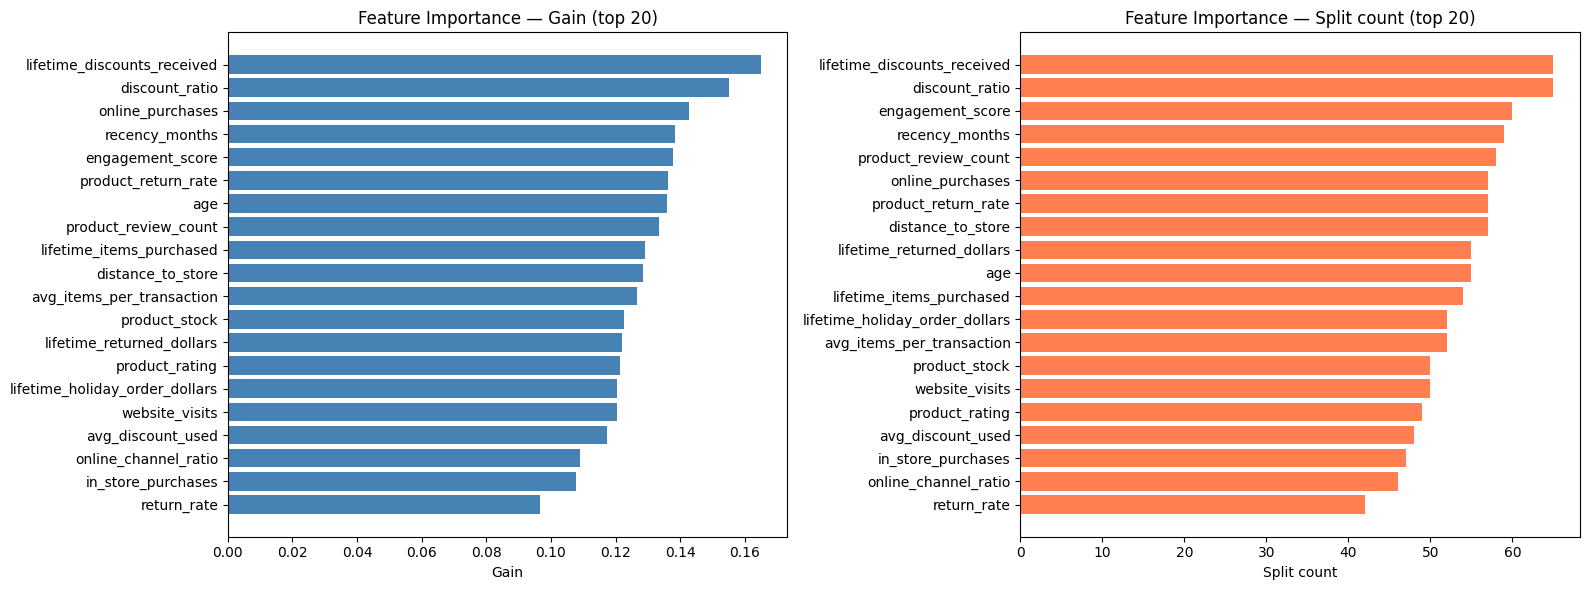

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top20 = fi_df.head(20)

axes[0].barh(top20["feature"][::-1], top20["importance_gain"][::-1], color="steelblue")
axes[0].set_title("Feature Importance — Gain (top 20)")
axes[0].set_xlabel("Gain")

top20_split = fi_df.sort_values("importance_split", ascending=False).head(20)
axes[1].barh(top20_split["feature"][::-1], top20_split["importance_split"][::-1], color="coral")
axes[1].set_title("Feature Importance — Split count (top 20)")
axes[1].set_xlabel("Split count")

plt.tight_layout()
plt.show()

## Section 8 — Score the Test Set

`predict()` returns a **continuous relevance score** per record.  
Higher score → higher predicted revenue → should appear earlier in the campaign list.


In [67]:
scores = final_model.predict(X_test)
print(f"Test records   : {len(scores):,}")
print(f"Unique scores  : {len(np.unique(scores)):,}")
print(f"Score range    : [{scores.min():.4f}, {scores.max():.4f}]")

results_df = pd.DataFrame({
    "customer_id":      df_test["customer_id"].values,
    "score":            scores,
    "true_total_sales": df_test[TARGET_COL].values,
})
results_df["rank"] = results_df["score"].rank(ascending=False, method="first").astype(int)
results_df = results_df.sort_values("rank").reset_index(drop=True)

print("\n── Top 20 ranked customers ──")
results_df.head(20)

Test records   : 150,000
Unique scores  : 126,098
Score range    : [-0.1707, 0.3990]

── Top 20 ranked customers ──


,customer_id,score,true_total_sales,rank
0,492676,0.398961,384.11,1
1,705222,0.326465,2839.48,2
2,235811,0.322194,4229.51,3
3,258185,0.320106,2964.50,4
4,559981,0.315940,8002.52,5
5,707256,0.315708,513.94,6
6,871639,0.298930,7939.06,7
7,624274,0.293779,482.24,8
8,264135,0.290287,9888.61,9
9,14726,0.286814,3718.46,10


## Section 9 — Hyperopt Convergence Analysis

Inspect the `Trials` object to see how the search progressed.


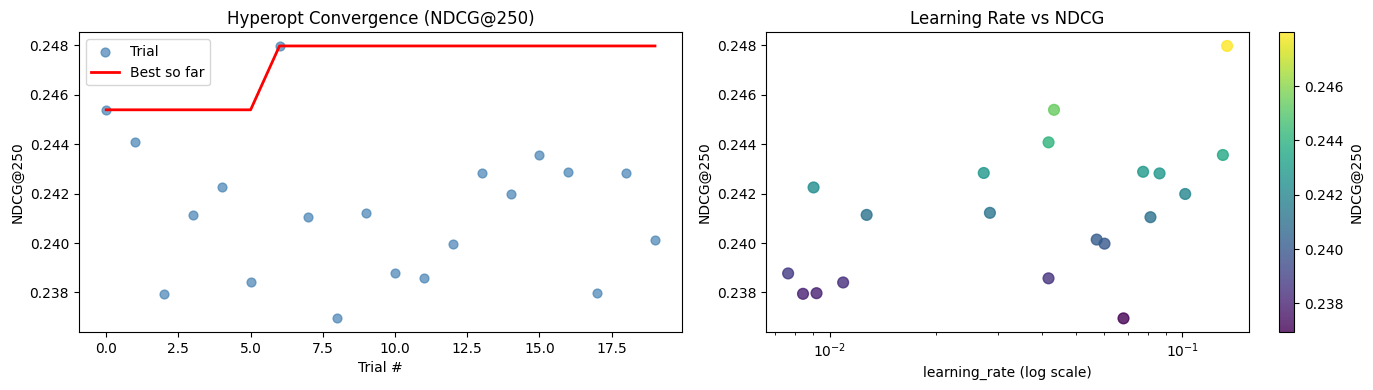

In [70]:
losses = [t["result"]["loss"] for t in trials.trials]
best_so_far = np.minimum.accumulate(losses)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(range(len(losses)), [-l for l in losses],
                c="steelblue", alpha=0.7, s=40, label="Trial")
axes[0].plot(range(len(best_so_far)), [-l for l in best_so_far],
             "r-", linewidth=2, label="Best so far")
axes[0].set_title(f"Hyperopt Convergence (NDCG@{k_val})")
axes[0].set_xlabel("Trial #")
axes[0].set_ylabel(f"NDCG@{k_val}")
axes[0].legend()

lrs   = [t["misc"]["vals"]["learning_rate"][0]   for t in trials.trials]
ndcgs = [-l for l in losses]
sc = axes[1].scatter(lrs, ndcgs, c=ndcgs, cmap="viridis", s=60, alpha=0.8)
plt.colorbar(sc, ax=axes[1], label=f"NDCG@{k_val}")
axes[1].set_title("Learning Rate vs NDCG")
axes[1].set_xlabel("learning_rate (log scale)")
axes[1].set_xscale("log")
axes[1].set_ylabel(f"NDCG@{k_val}")

plt.tight_layout()
plt.show()


In [71]:
# Full trial history table
trial_history = pd.DataFrame([{
    "trial":            i,
    "num_leaves":       int(t["misc"]["vals"]["num_leaves"][0]),
    "feature_fraction": round(t["misc"]["vals"]["feature_fraction"][0], 3),
    "learning_rate":    round(t["misc"]["vals"]["learning_rate"][0], 6),
    f"ndcg@{k_val}":   round(-t["result"]["loss"], 6),
} for i, t in enumerate(trials.trials)])

trial_history.sort_values(f"ndcg@{k_val}", ascending=False).head(10)

,trial,num_leaves,feature_fraction,learning_rate,ndcg@250
6,6,48,0.65,0.134118,0.247981
0,0,54,0.95,0.043298,0.245396
1,1,24,0.95,0.041784,0.244078
15,15,58,0.70,0.130447,0.243566
16,16,58,0.95,0.077479,0.242887
13,13,12,0.65,0.027363,0.242838
18,18,22,0.65,0.086256,0.242821
4,4,36,0.70,0.009004,0.242252
14,14,22,0.60,0.101998,0.241987
9,9,26,0.75,0.028486,0.241224


## Section 10 — Save Outputs


In [ ]:
os.makedirs("results", exist_ok=True)

# 1. Ranked scores
results_df.to_csv("results/ranked_scores.csv", index=False)

# 2. Feature importance
fi_df.to_csv("results/feature_importance.csv", index=False)

# 3. Best hyperparameters
with open("results/best_hyperparameters.json", "w") as f:
    json.dump(best_raw, f, indent=4)

# 4. Trial history
trial_history.to_csv("results/hyperopt_trial_history.csv", index=False)

print("results/ranked_scores.csv")
print("results/feature_importance.csv")
print("results/best_hyperparameters.json")
print("results/hyperopt_trial_history.csv")
